In [3]:
import numpy as np
import pandas as pd
import os
import glob as gb
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv3D, BatchNormalization, MaxPooling3D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import metrics

import warnings
warnings.filterwarnings('ignore')

# Constants

In [4]:
NON_SHOP_LIFTER_PATH = "/kaggle/input/shoplifting-videos-dataset/Shop DataSet/non shop lifters"

SHOP_LIFTER_PATH = "/kaggle/input/shoplifting-videos-dataset/Shop DataSet/shop lifters"

CLASSES = ['non shop lifters', 'shop lifters']

NUM_FRAMES = 16

FRAME_SIZE = 128

In [5]:
def make_frames(video_path, num_frames=16, size=64):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        if i in frame_indices:
            frame = cv2.resize(frame, (size, size))
            frame = frame / 255.0
            frames.append(frame)

    cap.release()
    return np.array(frames)

In [6]:
def read_data(non_shop_liters_path, shop_lifter_path):
    X, y = [] ,[]
    non_shop_lifters_count, shop_lifters_count = 0, 0
    
    for filename in os.listdir(non_shop_liters_path):
        
        # Ignoring Duplicates _ Note: all duplicates has _1 in there file name   
        if ((filename != "shop_lifter_n_1.mp4" and  filename != "videppppsss_1.mp4") and filename.endswith("_1.mp4")):
            continue
        else:
            file_path = os.path.join(non_shop_liters_path, filename)
            X.append(make_frames(file_path, NUM_FRAMES, FRAME_SIZE))
            y.append(0)
            non_shop_lifters_count += 1

    for filename in os.listdir(shop_lifter_path):
        file_path = os.path.join(shop_lifter_path, filename)
        X.append(make_frames(file_path, NUM_FRAMES, FRAME_SIZE))
        y.append(1)
        shop_lifters_count += 1

    print(f"Non_Shop lifters: {non_shop_lifters_count}\nShop lifters: {shop_lifters_count}")
    return np.array(X), np.array(y)

In [7]:
X, y = read_data(NON_SHOP_LIFTER_PATH, SHOP_LIFTER_PATH)

Non_Shop lifters: 313
Shop lifters: 324


In [8]:
X.shape, y.shape

((637, 16, 128, 128, 3), (637,))

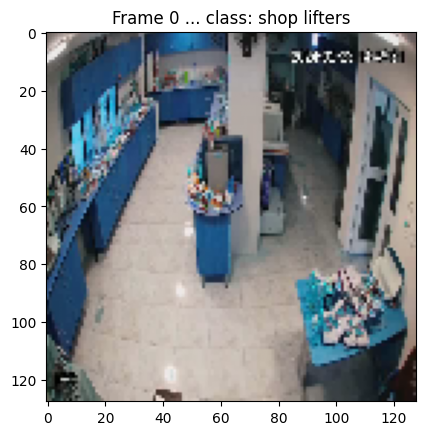

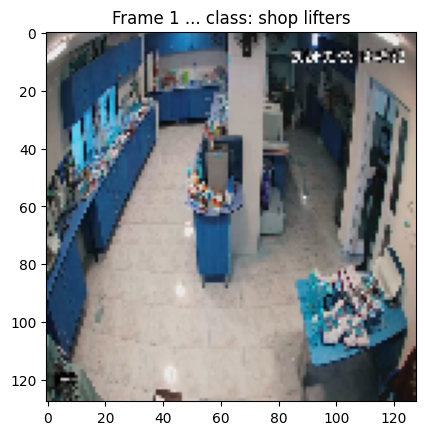

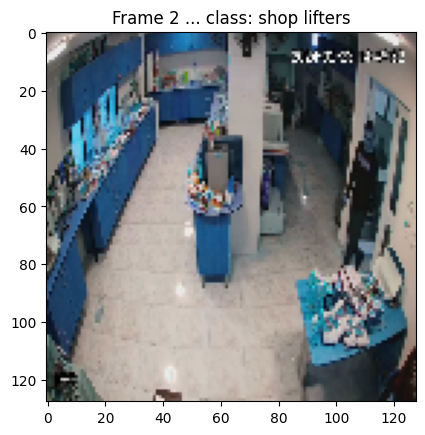

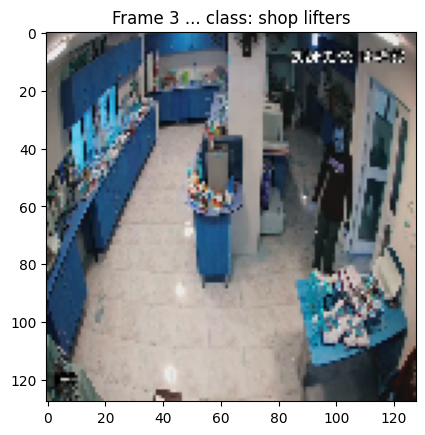

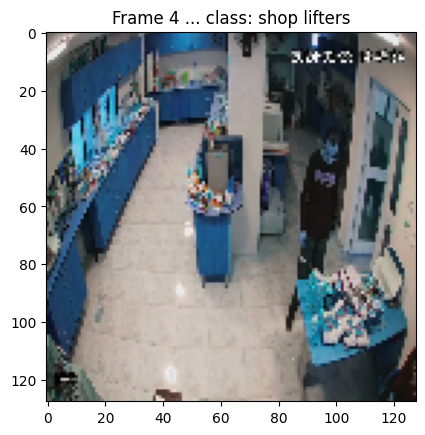

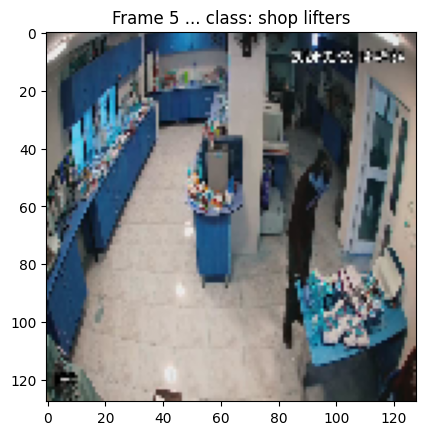

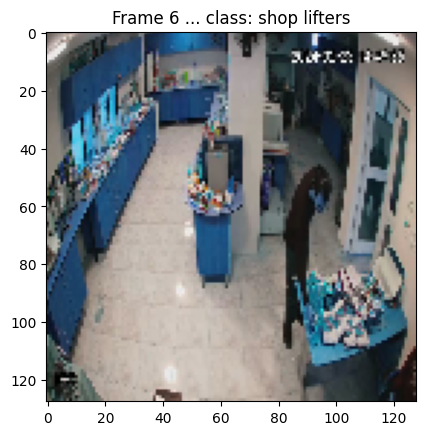

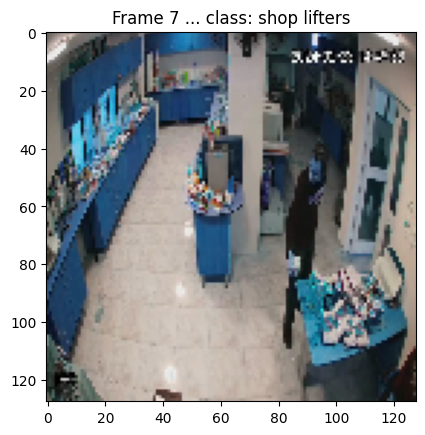

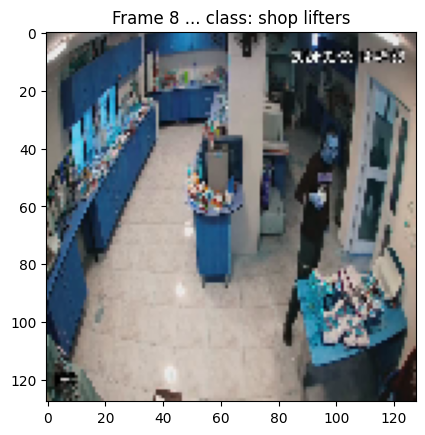

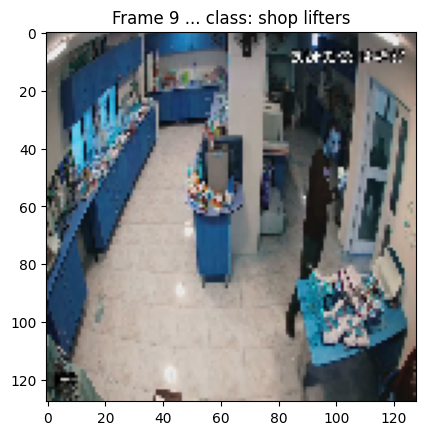

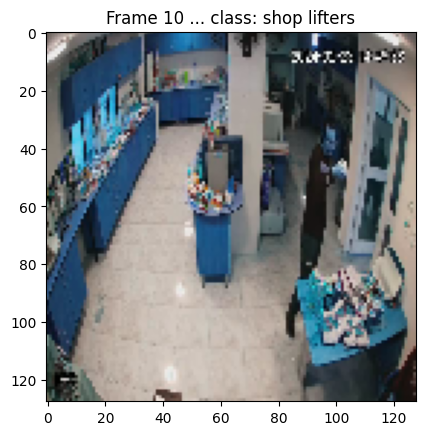

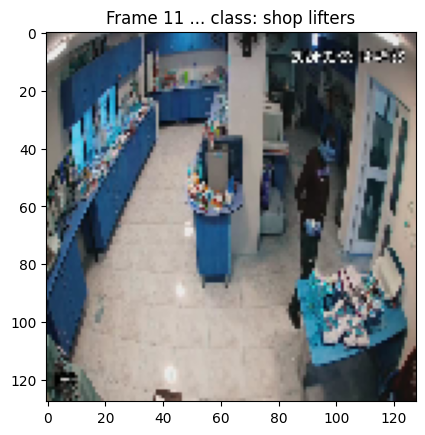

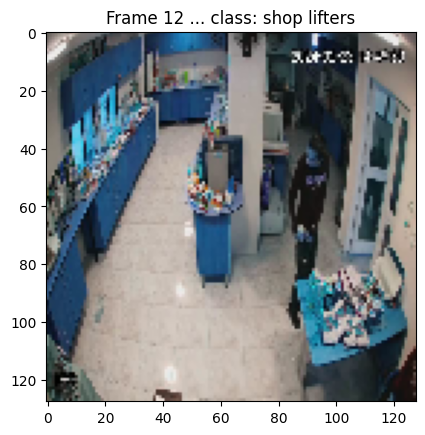

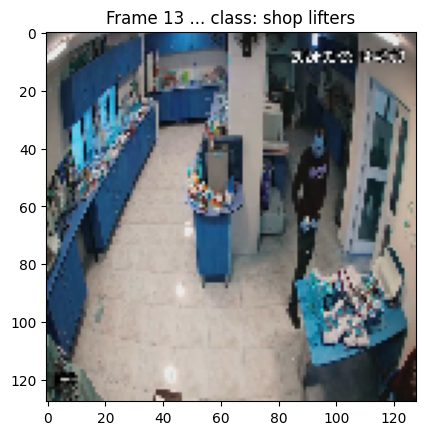

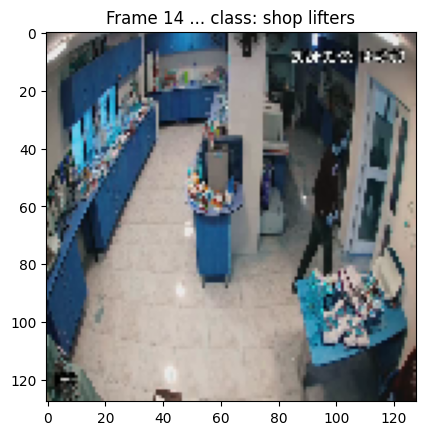

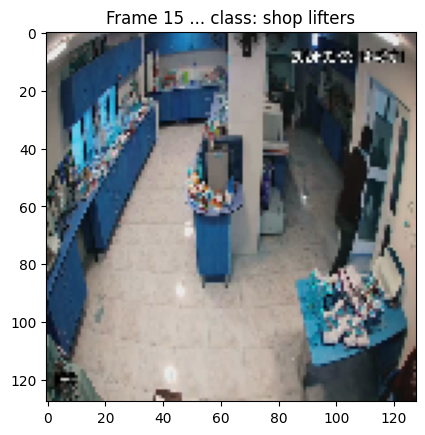

In [9]:
# Visualize first 16 frames of first video
for i in range(16):
    plt.imshow(X[313][i])
    plt.title(f'Frame {i} ... class: {CLASSES[y[313]]}')
    plt.show()

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

In [11]:
X_train.shape, X_test.shape, X_val.shape

((407, 16, 128, 128, 3), (128, 16, 128, 128, 3), (102, 16, 128, 128, 3))

In [12]:
y_train.shape, y_test.shape, y_val.shape

((407,), (128,), (102,))

In [43]:
del model
model = Sequential()

model = Sequential([
    Conv3D(32, kernel_size=(3,3,3), activation='relu', padding='same', input_shape=(NUM_FRAMES, FRAME_SIZE, FRAME_SIZE, 3)),
    MaxPooling3D(pool_size=(2,2,2)),
    
    Conv3D(64, kernel_size=(3,3,3), activation='relu', padding='same'),
    MaxPooling3D(pool_size=(2,2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_49 (Conv3D)              │ (None, 16, 128, 128,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_39 (MaxPooling3D) │ (None, 8, 64, 64, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_50 (Conv3D)              │ (None, 8, 64, 64, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_40 (MaxPooling3D) │ (None, 4, 32, 32, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,612,673 (128.22 MB)

 Trainable params: 33,612,673 (128.22 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(
    optimizer=Adam(learning_rate = 0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

# Callbacks
early_stoping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [45]:
history = model.fit(X_train,
                    y_train,
                    epochs = 50,
                    validation_data = (X_val, y_val),
                    callbacks = [early_stoping])

Epoch 1/50


2025-08-06 00:52:11.947696: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,32,8,64,64]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,8,64,64]{4,3,2,1,0}, f32[64,32,3,3,3]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-08-06 00:52:12.075538: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.12796133s
Trying algorithm eng0{} for conv (f32[32,32,8,64,64]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,8,64,64]{4,3,2,1,0}, f32[64,32,3,3,3]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardInput", backend_config={"c

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5146 - loss: 0.8535 - val_accuracy: 0.3922 - val_loss: 0.7920
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.4854 - loss: 0.7268 - val_accuracy: 0.3922 - val_loss: 0.6969
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 366ms/step - accuracy: 0.5894 - loss: 0.6680 - val_accuracy: 0.7451 - val_loss: 0.6639
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.6863 - loss: 0.6370 - val_accuracy: 0.3922 - val_loss: 0.6701
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.6141 - loss: 0.6384 - val_accuracy: 0.8039 - val_loss: 0.6115
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.7596 - loss: 0.5725 - val_accuracy: 0.8431 - val_loss: 0.5185
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 353ms/step - accuracy: 0.8065 - loss: 0.4718 - val_accuracy: 0.8137 - val_loss: 0.5021
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step - accuracy: 0.8843 - loss: 0.4035 - val_accuracy: 0.8039 - val_lo

In [46]:
model_eval = model.evaluate(X_train, y_train)
print("Loss of Model on train: ", model_eval[0])
print("Accuracy of Model on train:", round(model_eval[1]*100,2),'%\n\n')

model_eval = model.evaluate(X_val, y_val)
print("Loss of Model on validation: ", model_eval[0])
print("Accuracy of Model on validation:", round(model_eval[1]*100,2),'%\n\n')

model_eval = model.evaluate(X_test, y_test)
print("Loss of Model on test: ", model_eval[0])
print("Accuracy of Model on test:", round(model_eval[1]*100,2),'%')

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 1.0000 - loss: 0.0079
Loss of Model on train:  0.008784140460193157
Accuracy of Model on train: 100.0 %


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0340 
Loss of Model on validation:  0.026765575632452965
Accuracy of Model on validation: 100.0 %


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 1.0000 - loss: 0.0193
Loss of Model on test:  0.019052952527999878
Accuracy of Model on test: 100.0 %


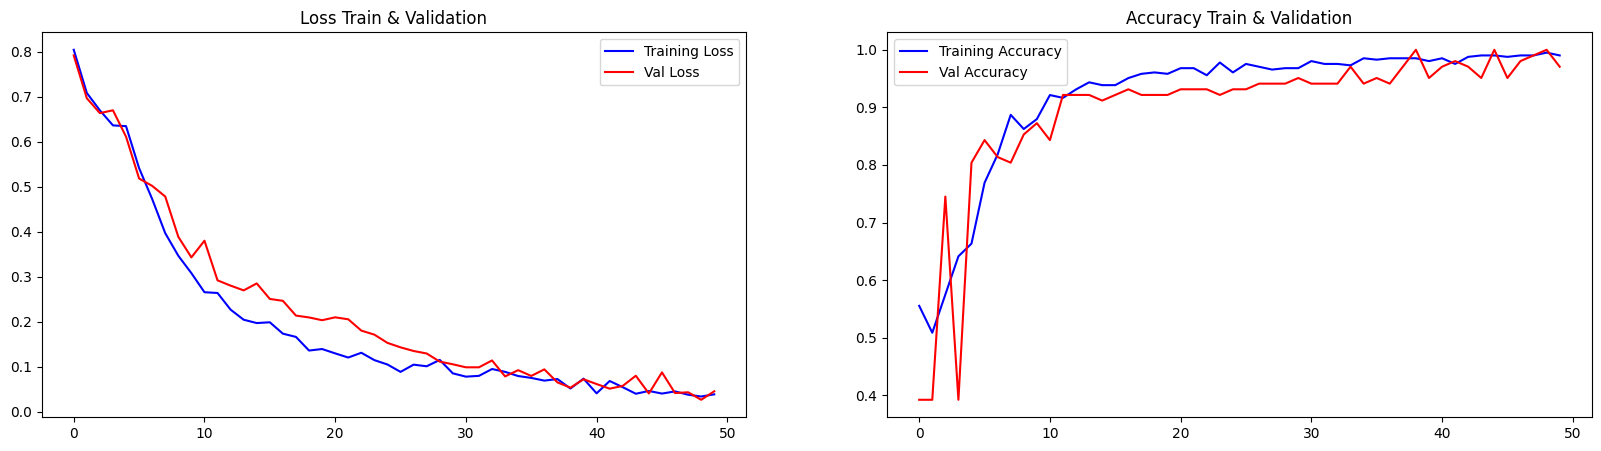

In [47]:
plt.figure(figsize = (20,5))

plt.subplot(1,2,1)
sns.lineplot(x=history.epoch, y=history.history['loss'], color='blue', label='Training Loss')
sns.lineplot(x=history.epoch, y=history.history['val_loss'], color='red', label='Val Loss')
plt.title('Loss Train & Validation')
plt.legend(loc='best')

plt.subplot(1,2,2)
sns.lineplot(x=history.epoch, y=history.history['accuracy'], color='blue', label='Training Accuracy')
sns.lineplot(x=history.epoch, y=history.history['val_accuracy'], color='red', label='Val Accuracy')
plt.title('Accuracy Train & Validation')
plt.legend(loc='best')

plt.show()

In [58]:
predicitions = model.predict(X_test)
predicitions = np.where(predicitions > 0.5,1,0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


In [59]:
print(classification_report(y_test, predicitions, target_names=CLASSES))

                  precision    recall  f1-score   support

non shop lifters       1.00      1.00      1.00        64
    shop lifters       1.00      1.00      1.00        64

        accuracy                           1.00       128
       macro avg       1.00      1.00      1.00       128
    weighted avg       1.00      1.00      1.00       128



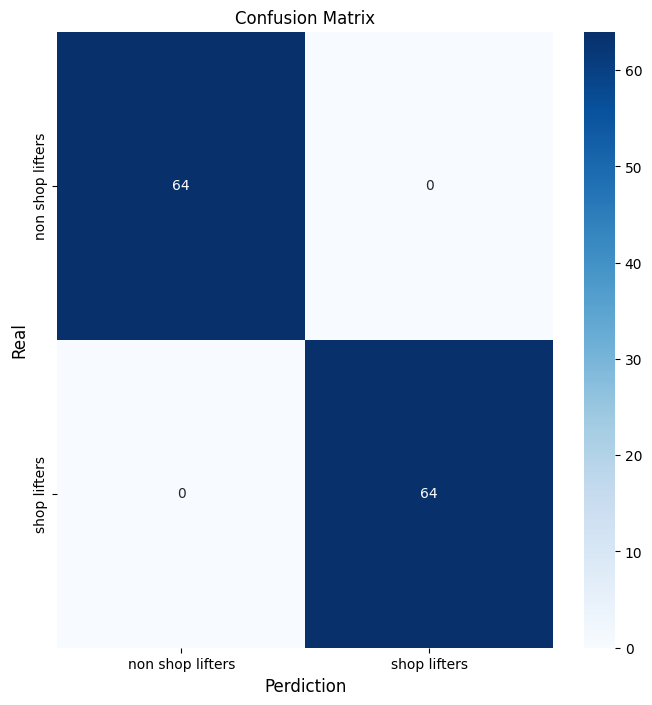

In [60]:
cm = confusion_matrix(y_test, predicitions)
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, xticklabels= CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Perdiction',fontsize = 12, color='black')
plt.ylabel('Real', fontsize = 12, color='black')
plt.title('Confusion Matrix')
plt.show()